In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

In [2]:
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [6]:
# 1. 경로 설정
BASE_PATH = r'D:\AiSon\DTS\BDW'
print("🔥 데이터 로딩 및 통합 분석 시작...")

🔥 데이터 로딩 및 통합 분석 시작...


In [7]:
# 2. 데이터 로드 (일자형 진행)
orders = pd.read_csv(os.path.join(BASE_PATH, 'olist_orders_dataset.csv'))
items = pd.read_csv(os.path.join(BASE_PATH, 'olist_order_items_dataset.csv'))
customers = pd.read_csv(os.path.join(BASE_PATH, 'olist_customers_dataset.csv'))
sellers = pd.read_csv(os.path.join(BASE_PATH, 'olist_sellers_dataset.csv'))
reviews = pd.read_csv(os.path.join(BASE_PATH, 'olist_order_reviews_dataset.csv'))
geo = pd.read_csv(os.path.join(BASE_PATH, 'olist_geolocation_dataset.csv'))
products = pd.read_csv(os.path.join(BASE_PATH, 'olist_products_dataset.csv'))
trans = pd.read_csv(os.path.join(BASE_PATH, 'product_category_name_translation.csv'))

In [8]:
# 3. 데이터 병합
df = orders.merge(items, on='order_id')
df = df.merge(customers[['customer_id', 'customer_zip_code_prefix']], on='customer_id')
df = df.merge(sellers[['seller_id', 'seller_zip_code_prefix']], on='seller_id')
df = df.merge(reviews[['order_id', 'review_score']], on='order_id')
products = products.merge(trans, on='product_category_name', how='left')
# 문제가 되었던 병합 코드 (이제 try 구문 밖이라 안전함)
df = df.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')

In [9]:
# 4. 거리 계산 (Haversine)
geo_avg = geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()
df = df.merge(geo_avg, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 'c_lat', 'geolocation_lng': 'c_lng'})
df = df.merge(geo_avg, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 's_lat', 'geolocation_lng': 's_lng'})

In [10]:
R = 6371
phi1, phi2 = np.radians(df['c_lat']), np.radians(df['s_lat'])
dphi = np.radians(df['s_lat'] - df['c_lat'])
dlambda = np.radians(df['s_lng'] - df['c_lng'])
a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2) * np.sin(dlambda/2)**2
df['distance_km'] = R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

In [11]:
print("✅ 데이터 로드 및 계산 완료. 분석 결과를 출력합니다.")

✅ 데이터 로드 및 계산 완료. 분석 결과를 출력합니다.


In [12]:
# ------------------------------------------------------------------
# 5. 제품별(ID) 집계
# ------------------------------------------------------------------
item_stats = df.groupby(['product_id', 'product_category_name_english']).agg({
    'order_id': 'count',       
    'review_score': 'mean',    
    'distance_km': 'mean',     
    'price': 'mean'            
}).reset_index()
item_stats.columns = ['Product_ID', 'Category', 'Volume', 'Score', 'Distance', 'Price']

# 신뢰도 필터 (최소 10개 이상 판매)
valid_items = item_stats[item_stats['Volume'] >= 10]
avg_dist = valid_items['Distance'].mean()

In [13]:
# ------------------------------------------------------------------
# 6. [Hero 분석] 장거리 + 고만족 (TOP 5)
# ------------------------------------------------------------------
hero_items = valid_items[
    (valid_items['Distance'] > avg_dist) & 
    (valid_items['Score'] >= 4.5)
].sort_values(by='Volume', ascending=False).head(5)

hero_display = hero_items.copy()
hero_display['Product_ID'] = hero_display['Product_ID'].str[:8] + "..."

print("\n" + "="*80)
print(f"🚀 [전략 1] Hero 개별 상품 TOP 5 (장거리 고만족)")
print(f"   * 전국 확장 타겟 (마진율이 높은지 확인 필요)")
print("="*80)
print(hero_display[['Category', 'Product_ID', 'Score', 'Distance', 'Volume', 'Price']].to_string(index=False))


🚀 [전략 1] Hero 개별 상품 TOP 5 (장거리 고만족)
   * 전국 확장 타겟 (마진율이 높은지 확인 필요)
             Category  Product_ID    Score    Distance  Volume      Price
           cool_stuff 5f504b3a... 4.555556  773.807212      63 598.950794
          electronics 6a8631b7... 4.709677  787.329773      62  26.641935
           housewares d696750e... 4.526316  682.305262      57 172.944912
                 food ed2067a9... 4.538462  599.969201      52  58.011346
computers_accessories 130482ad... 4.538462 1008.787072      52 105.000000


In [14]:
# ------------------------------------------------------------------
# 7. [Cash Cow 분석] 근거리 + 고매출 (TOP 10)
# ------------------------------------------------------------------
cow_items = valid_items[
    (valid_items['Distance'] < avg_dist) & 
    (valid_items['Score'] >= 4.0) 
].sort_values(by='Volume', ascending=False).head(10)

cow_display = cow_items.copy()
cow_display['Short_ID'] = cow_display['Product_ID'].str[:8] + "..."

print("\n" + "="*80)
print(f"💰 [전략 2] Cash Cow 개별 상품 TOP 10 (근거리 고매출)")
print(f"   * 절대 품절 금지 & 당일 배송 타겟")
print("="*80)
print(cow_display[['Category', 'Product_ID', 'Volume', 'Price', 'Distance', 'Score']].to_string(index=False))


💰 [전략 2] Cash Cow 개별 상품 TOP 10 (근거리 고매출)
   * 절대 품절 금지 & 당일 배송 타겟
                Category                       Product_ID  Volume      Price   Distance    Score
         furniture_decor aca2eb7d00ea1a7b8ebd4e68314663af     522  71.281992 444.882412 4.015326
   computers_accessories d1c427060a0f73f6b889a5c7c61f2ac4     339 137.606224 545.649890 4.194690
           health_beauty 154e7e31ebfa092203795c972e5804a6     289  22.509031 584.035957 4.307958
           health_beauty 437c05a395e9e47f9762e677a7068ce7     154  50.051494 357.749838 4.175325
          bed_bath_table f1c7f353075ce59d8a6f3cf58f419c9c     151 194.552053 569.118745 4.384106
            garden_tools c4baedd846ed09b85f78a781b522f126     149 100.597517 511.564521 4.201342
            garden_tools 8c591ab0ca519558779df02023177f44     141 102.781135 510.696854 4.134752
fashion_bags_accessories d017a2151d543a9885604dc62a3d9dcc     140  49.000000 489.793366 4.064286
           health_beauty e0cf79767c5b016251fe139915c59a26   

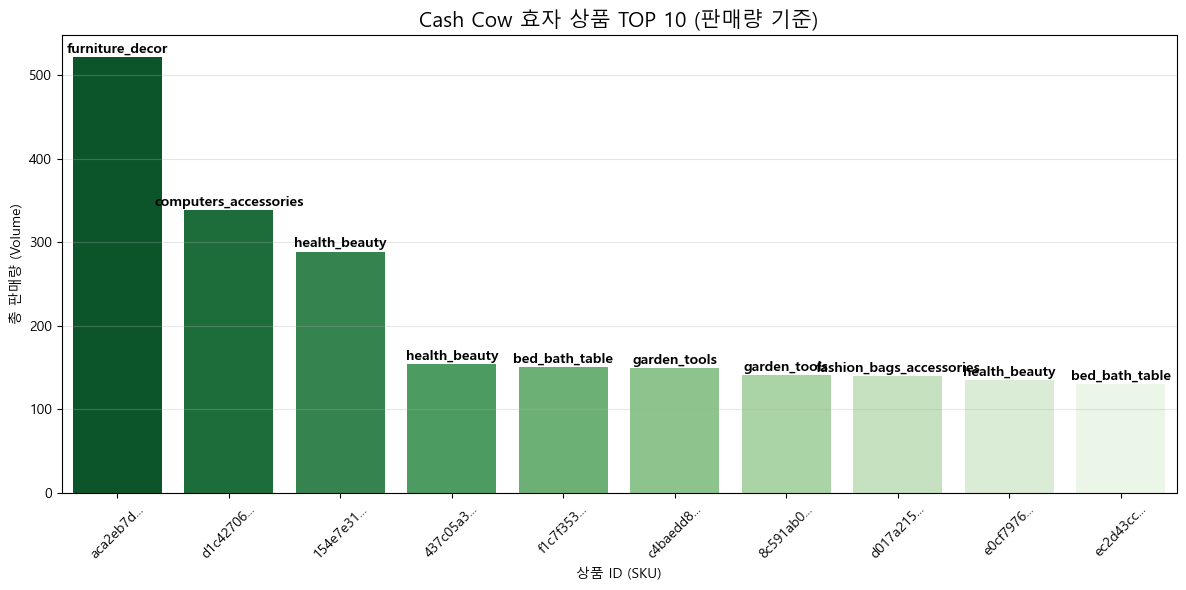

In [25]:
# ------------------------------------------------------------------
# 8. 시각화 (Cash Cow 중심)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 6))

barplot = sns.barplot(data=cow_display, x='Short_ID', y='Volume', palette='Greens_r')

for i, p in enumerate(barplot.patches):
    if i < len(cow_display): # 안전장치
        height = p.get_height()
        # 막대 바로 위에 카테고리 이름 출력
        barplot.text(p.get_x() + p.get_width()/2., height + 5, 
                     cow_display['Category'].iloc[i], 
                     ha="center", fontsize=10, fontweight='bold', color='black')

plt.title('Cash Cow 효자 상품 TOP 10 (판매량 기준)', fontsize=15)
plt.xlabel('상품 ID (SKU)')
plt.ylabel('총 판매량 (Volume)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

print()